In [19]:
from datetime import datetime
import MetaTrader5 as mt5
import pandas as pd
import pytz
import time
import matplotlib.pyplot as plt 

# import threading
mt5.initialize()


True

In [5]:
def price_action(symbol, lot, ask, bid, order_type):
    buy_profit=mt5.order_calc_profit(order_type,symbol,lot,ask,bid)
    return buy_profit
# price_action("EURUSD", 0.02, 1.17969, 1.18030,mt5.ORDER_TYPE_BUY)

In [2]:
def get_values(symbol):
    timezone = pytz.timezone("Etc/UTC")
    x = datetime.now()
    utc_from = datetime(2021, 2, 1, tzinfo=timezone)
    utc_to = datetime(x.year, x.month+1, x.day+1, tzinfo=timezone)
    # utc_to = datetime(x.year, x.month+1, 1, tzinfo=timezone)
    rates = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_H2, utc_from, utc_to)

    rates_frame = pd.DataFrame(rates)
    rates_frame = rates_frame.drop(['tick_volume', 'spread', 'real_volume'], axis=1)
    # convert time in seconds into the datetime format
    rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
    rates_frame = rates_frame.set_index('time')
    
    rates_frame['mean'] = (rates_frame['high'] + rates_frame['low'])/2

    # EMA = rates_frame['close'].ewm(span=100, adjust=False).mean()
    # DEMA = 2*EMA - EMA.ewm(span=100, adjust=False).mean()
    # rates_frame['dma'] = DEMA
#     rates_frame['P34'] = rates_frame['mean'].rolling(window=34).mean()
#     rates_frame['P5'] = rates_frame['mean'].rolling(window=5).mean()
# #     rates_frame = rates_frame.fillna(0)
#     rates_frame['AO'] = rates_frame['P5'] - rates_frame['P34']
#     rates_frame = rates_frame.drop(['high', 'low', 'mean', 'P34', 'P5'], axis=1)
    return rates_frame

In [4]:
a = get_values("USDCAD")


In [8]:
def rsi(df=a):
#     df = pd.read_csv('data.csv')

    # Calculate the price change for each period
    delta = df['close'].diff()

    # Define the period for the rolling average
    period = 7

    # Calculate the average gain and average loss for the specified period
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    # Calculate the Relative Strength (RS) by dividing the average gain by the average loss
    rs = avg_gain / avg_loss

    # Calculate the Relative Strength Index (RSI)
    rsi = 100 - (100 / (1 + rs))

    # Add the RSI to the dataframe
    df['RSI'] = rsi

    # Print the dataframe
    return df

In [26]:
df = rsi(a)
df['rsisma'] = df['RSI'].rolling(window=3).mean()
df['diff'] = df['RSI'] - df['rsisma']

<AxesSubplot:xlabel='time'>

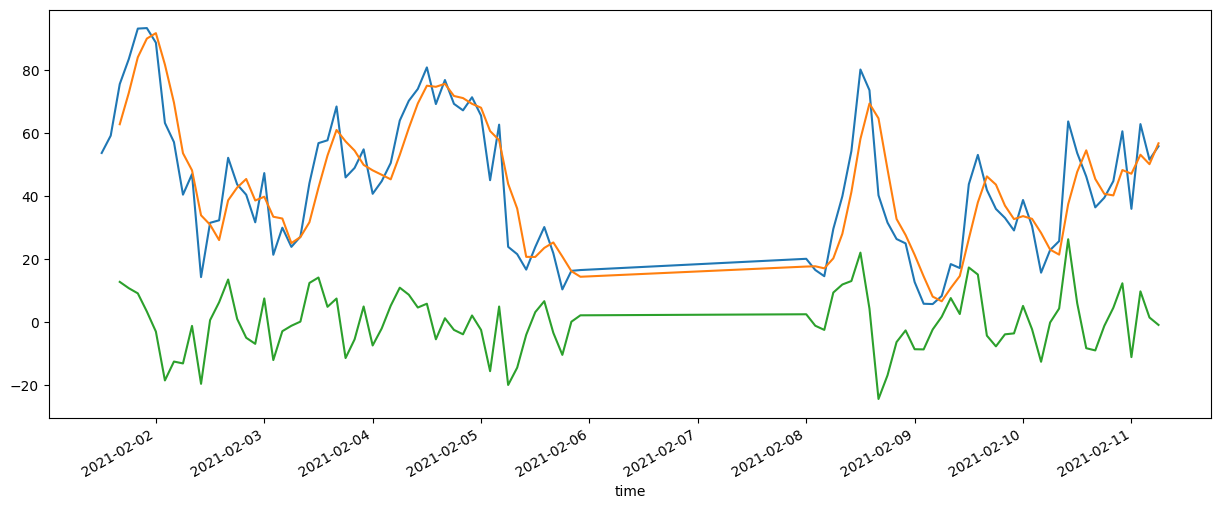

In [27]:
df['RSI'][:100].plot(figsize=(15,6))
df['rsisma'][:100].plot(figsize=(15,6))
df['diff'][:100].plot(figsize=(15,6))

In [28]:
df.tail()

,open,high,low,close,mean,RSI,rsisma,diff
time,,,,,,,,
2023-10-09 12:00:00,1.36609,1.36703,1.36538,1.36689,1.366205,56.424581,52.653803,3.770778
2023-10-09 14:00:00,1.36689,1.36694,1.36456,1.36474,1.365750,36.582809,48.710797,-12.127988
2023-10-09 16:00:00,1.36472,1.36475,1.36126,1.36304,1.363005,43.516209,45.507867,-1.991657
2023-10-09 18:00:00,1.36304,1.36328,1.36152,1.36212,1.362400,31.273644,37.124221,-5.850577
2023-10-09 20:00:00,1.36212,1.36222,1.35830,1.35865,1.360260,13.649564,29.479806,-15.830242


In [8]:
l = ['NR']
for i in range(1,len(a)):
    df = a.iloc[i].AO
    dfo = a.iloc[i-1].AO
    if str(df) == 'nan':
        l.append('NR')
    else:
        if df <= 0.0:
            if df > dfo:
                l.append('NG')
            elif df < dfo:
                l.append("NR")
            else:
                print(type(df))
                l.append('R')
        elif df > 0.0:
            if df > dfo:
                l.append('PG')
            elif df < dfo:
                l.append("PR")
            else:
                print(type(df))
                l.append('NR')
        else:
            l.append('NR')
a['signal'] = l

<class 'numpy.float64'>


In [9]:
B = []
check = 0
profit = []
index = []
indexB = 0
counter = 0
peck = 0
p= []
counterr = 0

for i in range(7, len(a)):
    df = a.iloc[i].signal
    dfo = a.iloc[i-1].signal
    if str(a.iloc[i].AO) != 'nan':
        if a.iloc[i].AO > -0.000500 and df == "NG" and check == 0:
            counter = 0
            for k in range(6,0, -1):
                if a.iloc[i-k].signal == "NG":
                    counter = counter + 1
                if a.iloc[i-k].signal == "NR":
                    break
        if counter == 6 and check == 0:
            B.append("buy")
            buy_price = a.iloc[i].close
            indexB = a.iloc[i].name
            print("#"*20)
            print(indexB)
            print("*"*20)
            
            check = 1
            counter = 0
        if check == 1:
            sell_price = a.iloc[i].close
            pp = price_action("EURUSD", 0.05, buy_price, sell_price, mt5.ORDER_TYPE_BUY)
            print(pp)
            if 'R' in df:
                print("R--{}".format(pp))
                check = 0
                index.append(a.iloc[i].name)
                print(a.iloc[i].name)
                profit.append([pp,indexB,a.iloc[i].name])
                p.append(pp)
            elif pp < -2.0:
                print("less--{}".format(pp))
                check = 0
                index.append(a.iloc[i].name)
                print(a.iloc[i].name)
                
                profit.append([pp,indexB,a.iloc[i].name])
                p.append(pp)
            else:
                counterr = 0
                index.append(0)
                B.append('nan')
#                 profit.append(0)


#     break
        
    
#     #860
#     a.iloc[i-2].AO == "PR" and a.iloc[i-2].AO == "PR" and a.iloc[i-2].AO > a.iloc[i-1].AO
#     #After ghad-bhad-2 NG PG goes up

# check for down also continuos red from PR to NR
#green aligator indicator crossing

####################
2021-02-03 23:00:00
********************
0.0
-1.15
3.05
0.4
-0.15
-1.45
R---1.45
2021-02-04 04:00:00
####################
2021-02-05 14:00:00
********************
0.0
7.25
15.9
17.2
22.7
24.25
26.5
26.6
29.85
29.9
26.45
R--26.45
2021-02-08 00:00:00
####################
2021-02-18 12:00:00
********************
0.0
2.7
5.5
9.05
2.0
2.8
5.4
7.7
6.9
R--6.9
2021-02-18 20:00:00
####################
2021-03-12 23:00:00
********************
0.0
-1.9
R---1.9
2021-03-15 00:00:00
####################
2021-03-17 17:00:00
********************
0.0
-1.2
1.1
36.65
36.55
36.95
38.1
37.25
39.4
40.7
R--40.7
2021-03-18 02:00:00
####################
2021-04-23 09:00:00
********************
0.0
9.45
11.75
10.45
11.0
11.55
18.25
13.05
7.15
R--7.15
2021-04-23 17:00:00
####################
2021-05-03 16:00:00
********************
0.0
8.1
0.7
-2.2
less---2.2
2021-05-03 19:00:00
####################
2021-05-06 05:00:00
********************
0.0
-0.6
R---0.6
2021-05-06 06:00:00
###############

####################
2022-09-02 12:00:00
********************
0.0
-3.75
less---3.75
2022-09-02 13:00:00
####################
2022-09-06 02:00:00
********************
0.0
9.0
6.85
4.2
-3.15
less---3.15
2022-09-06 06:00:00
####################
2022-09-22 15:00:00
********************
0.0
-19.7
R---19.7
2022-09-22 16:00:00
####################
2022-09-27 08:00:00
********************
0.0
-3.5
less---3.5
2022-09-27 09:00:00
####################
2022-10-13 03:00:00
********************
0.0
-4.55
less---4.55
2022-10-13 04:00:00
####################
2022-10-20 14:00:00
********************
0.0
-4.95
less---4.95
2022-10-20 15:00:00
####################
2022-11-01 09:00:00
********************
0.0
-3.85
less---3.85
2022-11-01 10:00:00
####################
2022-11-04 08:00:00
********************
0.0
-8.2
less---8.2
2022-11-04 09:00:00
####################
2022-11-18 02:00:00
********************
0.0
-1.7
-1.65
5.75
-3.0
less---3.0
2022-11-18 06:00:00
####################
2022-11-22 09:00:00
***

In [10]:
sum(p)

-256.2

In [11]:
profit

[[-1.45, Timestamp('2021-02-03 23:00:00'), Timestamp('2021-02-04 04:00:00')],
 [26.45, Timestamp('2021-02-05 14:00:00'), Timestamp('2021-02-08 00:00:00')],
 [6.9, Timestamp('2021-02-18 12:00:00'), Timestamp('2021-02-18 20:00:00')],
 [-1.9, Timestamp('2021-03-12 23:00:00'), Timestamp('2021-03-15 00:00:00')],
 [40.7, Timestamp('2021-03-17 17:00:00'), Timestamp('2021-03-18 02:00:00')],
 [7.15, Timestamp('2021-04-23 09:00:00'), Timestamp('2021-04-23 17:00:00')],
 [-2.2, Timestamp('2021-05-03 16:00:00'), Timestamp('2021-05-03 19:00:00')],
 [-0.6, Timestamp('2021-05-06 05:00:00'), Timestamp('2021-05-06 06:00:00')],
 [11.5, Timestamp('2021-05-20 16:00:00'), Timestamp('2021-05-21 07:00:00')],
 [-0.35, Timestamp('2021-06-02 22:00:00'), Timestamp('2021-06-03 00:00:00')],
 [1.85, Timestamp('2021-06-10 18:00:00'), Timestamp('2021-06-10 19:00:00')],
 [-2.9, Timestamp('2021-06-14 17:00:00'), Timestamp('2021-06-14 21:00:00')],
 [2.4, Timestamp('2021-06-30 08:00:00'), Timestamp('2021-06-30 10:00:00')]

In [509]:
for i in range(len(p)):
    if p[i]!=0:
        print(p[i])

1.22
-0.74
-0.5
0.44
3.06
0.62
2.9
0.52
0.62
1.34
-1.38
-2.32
0.56
4.0
0.86
-3.66
-0.02
0.6
0.04
-1.6600000000000001
1.08
1.42
0.32
0.92
1.22
1.3
4.62
1.8399999999999999
-1.46
0.56
-0.76
0.44
0.58
0.86
1.34
-7.74
-4.9
-2.2
2.1
3.7800000000000002
2.6
-2.36
1.7
1.3599999999999999
-2.06
-1.3
3.24
0.4
-0.78
-0.68
1.42
0.68
-0.3
1.02
0.44
-4.5
-3.7800000000000002
1.22
0.4
0.66
-0.24
0.76
0.74
0.48
1.6
0.1
0.8
1.6
2.98
1.54
-0.1
-0.16
0.66
0.54
4.38
0.62
-0.24
0.72
-2.08
-1.54
0.64
0.42
1.5
2.08
-3.82
0.82
-1.2
-1.74
1.88
-5.88
1.38
-0.9
0.78
-1.8599999999999999
1.18
-0.56
0.44
-2.2
-3.12
0.48
-1.54
0.46
-0.52
0.74
-1.08
-0.16
0.66
-4.06
1.78
0.42
-1.4
2.24
1.26
1.98
-4.5
-1.06
-1.18
4.0
-2.46
0.88
-2.36
-0.3
0.38
1.62
-3.62
1.4
0.38
0.48
-2.18
-3.02
-0.88
1.1
1.96
4.5600000000000005
-3.24
1.26
0.92
0.38
1.0
0.72
0.54
-0.5
0.32
-6.32
-2.16
0.8
1.74
-3.5
0.38


In [480]:
for i in range(len(profit)):
    if profit[i]!=0:
        print(str(profit[i])+"----"+str(index[i]))
    elif B[i]=='buy':
        print(indexB[i])

64.18----2021-02-01 07:00:00
64.18----2021-02-01 07:00:00
1.22----2021-02-04 01:00:00
2021-02-04 05:00:00
-0.74----2021-02-04 04:00:00
2021-02-04 07:00:00
2021-02-04 08:00:00
2021-02-04 09:00:00
2021-02-04 10:00:00
2021-02-04 11:00:00
2021-02-04 12:00:00
2021-02-04 13:00:00
2021-02-04 14:00:00
2021-02-04 15:00:00
2021-02-04 16:00:00
2021-02-04 18:00:00
-0.5----2021-02-04 17:00:00
2021-02-04 20:00:00
2021-02-04 21:00:00
2021-02-04 22:00:00
2021-02-04 23:00:00
2021-02-05 00:00:00
0.44----2021-02-05 01:00:00
3.06----2021-02-05 10:00:00
0.62----2021-02-05 13:00:00
2.9----2021-02-05 15:00:00
0.52----2021-02-05 17:00:00
0.62----2021-02-05 19:00:00
1.34----2021-02-05 22:00:00
2021-02-08 01:00:00
-1.38----2021-02-08 00:00:00
2021-02-08 03:00:00
2021-02-08 04:00:00
2021-02-08 05:00:00
2021-02-08 06:00:00
2021-02-08 07:00:00
2021-02-08 08:00:00
2021-02-08 09:00:00
2021-02-08 10:00:00
2021-02-08 11:00:00
2021-02-08 12:00:00
2021-02-08 13:00:00
2021-02-08 14:00:00
2021-02-08 15:00:00
2021-02-08 16

IndexError: list index out of range

In [476]:
# for i,j in a.iterrows():
#     print(j.AO, j.signal)

In [ ]:
    if df == 'PG' and dfo == 'NG' and check == 0:
        B.append("buy")
        buy_price = a.iloc[i].close
        indexB.append(a.iloc[i].name)
        check = 1
    else:
        index.append(0)
        B.append('nan')
        profit.append(0)
        indexB.append(0)
    if check == 1:
        sell_price = a.iloc[i].close
        pp = price_action("EURUSD", 0.05, buy_price, sell_price,mt5.ORDER_TYPE_BUY)
        if pp > 0.30:
            check = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
        if 'R' in df:     
            check = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
        elif pp < -3.0:
            check = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
            
        else:
            index.append(0)
            B.append('nan')
            profit.append(0)
            indexB.append(0)
            
#         elif 'R' in df:
#             counter = counter + 1
#             if counter == 2:
#                 check = 0
#                 index.append(a.iloc[i].name)
#                 profit.append(pp)
            
#         else:
#             counter = 0
#             index.append(0)
#             B.append('nan')
#             profit.append(0)
#             indexB.append(0)





    
    

In [ ]:
    if df == "PG" and dfo == "PR" and a.iloc[i-1].AO < 0.000900 and check ==0:
        B.append("buy")
        buy_price = a.iloc[i].close
        indexB.append(a.iloc[i].name)
        print("#"*20)
        print(a.iloc[i].name)
        print("*"*20)
        check = 1    
        
    if check == 1:
        sell_price = a.iloc[i].close
        pp = price_action("EURUSD", 0.02, buy_price, sell_price,mt5.ORDER_TYPE_BUY)
        print(pp)
        if pp > 0.30:
            check = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
        if 'R' in df:     
            check = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
        elif pp < -2.0:
            check = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
            
        else:
            index.append(0)
            B.append('nan')
            profit.append(0)
            indexB.append(0)

In [ ]:
    if df == "PG" and dfo == "NG" and check == 0:
        B.append("buy")
        buy_price = a.iloc[i].close
        indexB.append(a.iloc[i].name)
#         print("#"*20)
#         print(a.iloc[i].name)
#         print("*"*20)
        check = 1
        
    if df == "PG" and dfo == "NG" and peck == 0:
        B.append("buy")
        buy_price1 = a.iloc[i].close
        indexB.append(a.iloc[i].name)
#         print("#"*20)
#         print(a.iloc[i].name)
#         print("*"*20)
        peck = 1
        
        
        
    if peck == 1:
        sell_price = a.iloc[i].close
        pp = price_action("EURUSD", 0.02, buy_price1, sell_price,mt5.ORDER_TYPE_BUY)
#         print(pp)
        
        if pp > 20.0:
            profit.append(pp)
            index.append(a.iloc[i].name)
            peck = 0
            
        

#         if 'R' in df:
#             counter = counter + 1
#             if counter == 2:
#                 print(pp)
#                 check = 0
#                 index.append(a.iloc[i].name)
#                 profit.append(pp)
            
        if pp < -2.0:
            print("cjeck")
            peck = 0
            counter = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
            
        else:
            index.append(0)
            B.append('nan')
            profit.append(0)
            indexB.append(0)
             
    if check == 1:
        sell_price = a.iloc[i].close
        pp = price_action("EURUSD", 0.02, buy_price, sell_price,mt5.ORDER_TYPE_BUY)
        print(pp)
        
        if pp > 10.0:
            profit.append(pp)
            index.append(a.iloc[i].name)
            check = 0
            
        

#         if 'R' in df:
#             counter = counter + 1
#             if counter == 2:
#                 print(pp)
#                 check = 0
#                 index.append(a.iloc[i].name)
#                 profit.append(pp)
            
        if pp < -2.0:
            print("cjeck")
#             print(pp)
            check = 0
            counter = 0
            index.append(a.iloc[i].name)
            profit.append(pp)
            
        else:
            index.append(0)
            B.append('nan')
            profit.append(0)
            indexB.append(0)
             
    

            
    else:
        counter = 0
        index.append(0)
        B.append('nan')
        profit.append(0)
        indexB.append(0)

#         if 'R' in df:     
#             check = 0
#             index.append(a.iloc[i].name)
#             profit.append(pp)
